In [41]:
!pip install pennylane 

## PennyLane 101
- Quantum functions and QNodes
- Devices
- Templates
- Debugging tips


In [42]:
# import pennylane 
import pennylane as qp
qp.about()
# Go to pennylane.ai to see if you're using the mose stable version

Name: pennylane
Version: 0.45.0
Summary: PennyLane is a cross-platform Python library for quantum computing, quantum machine learning, and quantum chemistry. Train a quantum computer the same way as a neural network.
Home-page: 
Author: 
License: 
Location: C:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages
Platform info:           Windows-11-10.0.26120-SP0
Python version:          3.12.4
Numpy version:           2.4.5
Scipy version:           1.17.1
JAX version:             None
Catalyst version:        None
Installed devices:
- default.clifford (pennylane-0.45.0)
- default.gaussian (pennylane-0.45.0)
- default.mixed (pennylane-0.45.0)
- default.qubit (pennylane-0.45.0)
- default.qutrit (pennylane-0.45.0)
- default.qutrit.mixed (pennylane-0.45.0)
- default.tensor (pennylane-0.45.0)
- null.qubit (pennylane-0.45.0)
- reference.qubit (pennylane-0.45.0)
- lightning.qubit (pennylane_lightning-0.45.0)


## Quantum functions ans QNodes 
A quantum function is just a Python function and includes quantum gates and measurements 

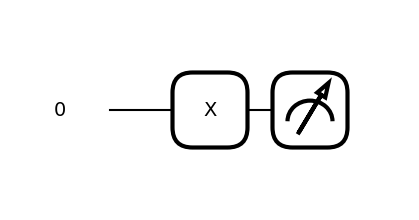

In [43]:
# This is a quantum fuction 
def circuit(): 
    qp.X(wires=0)
    return qp.probs()

qp.draw_mpl(circuit)();

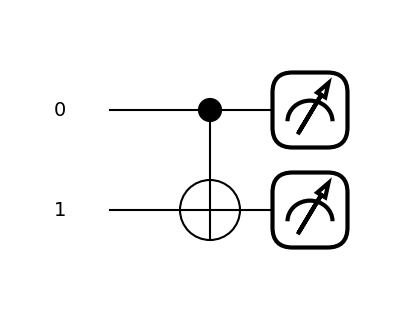

In [44]:
# This is another guantum function 
def circuit2(): 
    qp.CNOT(wires=[0, 1])
    return qp.probs()

qp.draw_mpl(circuit2)();

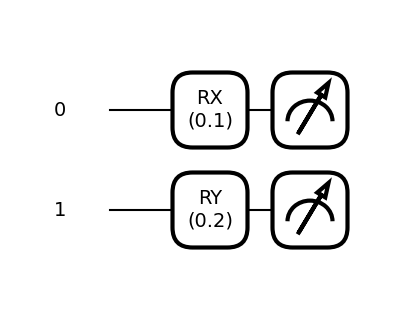

In [45]:
# This is a quantum function where the gates take parameter 
def circuit3(x,y):
    qp.RX(x, wires=0)
    qp.RY(y, wires=1)
    return qp.probs()

qp.draw_mpl(circuit3, decimals = 1)(0.1, 0.2); 

QNodes allow you to run your function on a specific device(simulator or actual quantum hardware)

## PenyLane 102 



In [46]:
# device 
dev = qp.device("default.qubit")

# This is a qnode (this is the preferred way to create a qnode) 

@qp.qnode(dev) 
def circuit3(x,y):
    qp.RX(x, wires=0)
    qp.RY(y, wires=0)
    return qp.probs()

# This is also a qnode 
qnode1 = qp.QNode(circuit2, dev)

# Run your circuit by simply calling the function 
#circuit3(0.1,0.2)

qnode1()
    

array([1., 0., 0., 0.])

The output tells us that there's over 90% chance to measure our qubit in the |0> state and only a small chance of measuring our qubit in the |1> state. 

### Devices 
Tips : lightning.qubit and default.qubit are usually a safe bet

In [47]:
# Peioritize default.qubit for small simulator 

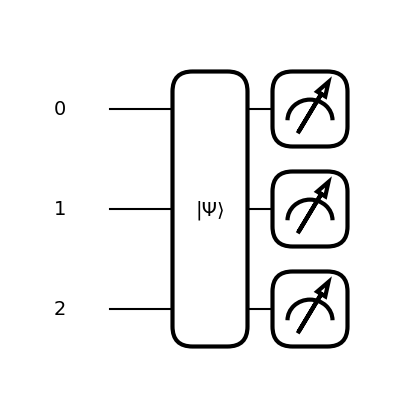

In [48]:
# Create a qnode 

@qp.qnode(dev)
def circuit4():
    # add the template within the function and apply it on a specific set of wires 
    qp.BasisEmbedding([0,1,0], wires=[0,1,2])

    # return a measurement
    return qp.probs()

# Draw your circuit
qp.draw_mpl(circuit4)();

array([0., 1.])

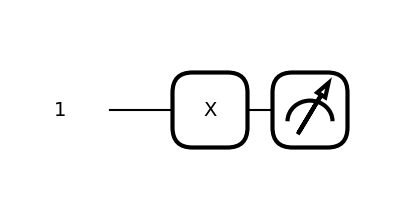

In [49]:
# You can decompose the template into different gate sets
# Decompose this circuit into Clifford + T gates
decomp = qp.decompose(circuit4, gate_set=qp.gate_sets.CLIFFORD_T)

# Draw your circuit
qp.draw_mpl(decomp, show_all_wires = True)(); 

# Run your circuit 
decomp()

## PennyLane Built-in simulator 
explore them on pennnylane's website